In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import torchvision.utils as vutils
import os
import kagglehub
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
# Parametros
latent_dim       = 100
img_channels     = 3
img_size         = 64
batch_size       = 512       # Batch maior para utilizar melhor a GPU
epochs           = 150       
learning_rate_G  = 0.0002    # G usa o dobro do LR
learning_rate_D  = 0.0001    # LR menor para estabilidade
beta1, beta2     = 0.5, 0.999
max_samples      = None
num_workers      = 4
save_interval    = 10        # Salvar a cada 10 epochs
sample_interval  = 5         # Gerar amostras para criar o GIF
checkpoint_dir   = "/kaggle/working/checkpoints"
sample_dir       = "/kaggle/working/samples"
use_amp          = True      # Usar AMP para acelerar o treinamento

os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(sample_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

if use_amp and not torch.cuda.is_available():
    use_amp = False


Training on: cuda


In [ ]:
# Dataset e limpeza
print("Checking / downloading CelebA dataset...")
dataset_path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

class FilteredCelebADataset(Dataset):
    # Dataset limpo para manter apenas imagens de rostos frontais sem acessórios.

    
    # Attribute filter  — remove óculos, chapéus e barbas.
    # Geometric filter  — computa a simetria facial usando as coordenadas dos olhos e nariz.


    def __init__(self, root_dir, transform=None, max_samples=None):
        self.root_dir = root_dir
        self.transform = transform
        self.img_dir = os.path.join(root_dir, "img_align_celeba", "img_align_celeba")
        if not os.path.exists(self.img_dir):
            self.img_dir = os.path.join(root_dir, "img_align_celeba")

        # Carrega os arquivos CSV e faz o merge para ter atributos e landmarks
        df_attr      = pd.read_csv(os.path.join(root_dir, "list_attr_celeba.csv"))
        df_landmarks = pd.read_csv(os.path.join(root_dir, "list_landmarks_align_celeba.csv"))
        df = pd.merge(df_attr, df_landmarks, on="image_id")
        total_orig = len(df)

        # Attribute filter: remove óculos, chapéus e barbas
        filtro_attr = (
            (df["Eyeglasses"] == -1) &
            (df["Wearing_Hat"] == -1) &
            (df["No_Beard"]    ==  1)
        )

        # Geometric filter: simetria facial usando olhos e nariz
        dist_esq = (df["nose_x"] - df["lefteye_x"]).astype(float)
        dist_dir = (df["righteye_x"] - df["nose_x"]).astype(float)

        positive_distances = (dist_esq > 0) & (dist_dir > 0)

        simetria = dist_esq / dist_dir.clip(lower=1e-6)

        filtro_frontal = (simetria > 0.75) & (simetria < 1.333) & positive_distances

        df_filtrado = df[filtro_attr & filtro_frontal].copy()
        total_filt  = len(df_filtrado)

        print("\n─── Dataset Curation Statistics ──────────────────────")
        print(f"  Original count          : {total_orig:>9,}")
        print(f"  After curation filters  : {total_filt:>9,}")

        # FIX 2: random sample instead of .head() to eliminate ordering bias
        if max_samples and max_samples < total_filt:
            df_filtrado = df_filtrado.sample(n=max_samples, random_state=42)
            print(f"  Random subset used      : {len(df_filtrado):>9,}")
        print("──────────────────────────────────────────────────────\n")

        self.image_files = df_filtrado["image_id"].values

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.image_files[idx])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, 0


transform = transforms.Compose([
    transforms.CenterCrop(160),
    # LANCZOS faz downsampling preservando detalhes faciais
    transforms.Resize((img_size, img_size),
                      interpolation=transforms.InterpolationMode.LANCZOS),
    # Aumenta a diversidade de poses e expressões, ajudando o modelo a generalizar melhor.
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

dataset = FilteredCelebADataset(
    root_dir=dataset_path,
    transform=transform,
    max_samples=max_samples,
)
dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available(),   # melhora a transferência para GPU
    drop_last=True,
    persistent_workers=(num_workers > 0),
    prefetch_factor=(2 if num_workers > 0 else None),
)
print(f"DataLoader ready: {len(dataset):,} images  |  {len(dataloader)} batches/epoch")


Checking / downloading CelebA dataset...

─── Dataset Curation Statistics ──────────────────────
  Original count          :   202,599
  After curation filters  :    63,183
──────────────────────────────────────────────────────

DataLoader ready: 63,183 images  |  123 batches/epoch


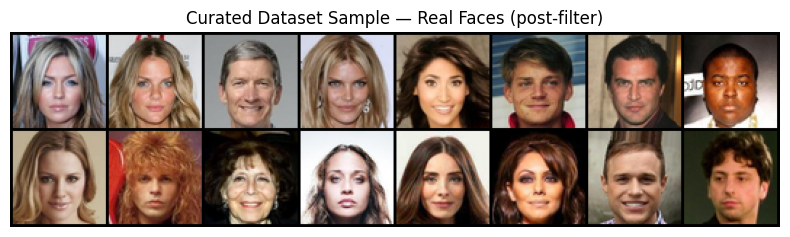

In [ ]:
# Visualização curadoria
def show_real_batch(loader):
    batch = next(iter(loader))
    plt.figure(figsize=(8, 8))
    plt.axis("off")
    plt.title("Curated Dataset Sample — Real Faces (post-filter)")
    plt.imshow(
        np.transpose(
            vutils.make_grid(batch[0][:16], padding=2, normalize=True).cpu(),
            (1, 2, 0)
        )
    )
    plt.tight_layout()
    plt.savefig(os.path.join(sample_dir, "real_samples.png"), dpi=150)
    plt.show()

show_real_batch(dataloader)


In [ ]:
# Modelos e inicialização

def weights_init(m):
    cls = m.__class__.__name__
    if "Conv" in cls:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in cls:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

ngf, ndf = 64, 64


class Generator(nn.Module):
    # Gerador DCGAN: vetor latente z para imagem RGB 64×64.
    # BatchNorm + ReLU em cada camada oculta, Tanh na saída.
    
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            # z (latent_dim×1×1)  4×4
            nn.ConvTranspose2d(latent_dim, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # 4×4 - 8×8
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # 8×8 - 16×16
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # 16×16 - 32×32
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # 32×32 - 64×64
            nn.ConvTranspose2d(ngf, img_channels, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, x):
        return self.main(x)


class Discriminator(nn.Module):
    # Discriminador DCGAN: imagem RGB 64×64 para logit escalar.
    # BatchNorm + LeakyReLU em cada camada oculta, sem Sigmoid na saída.
    
    def __init__(self):
        super().__init__()
        sn = nn.utils.spectral_norm

        self.main = nn.Sequential(
            # 64×64 - 32×32
            sn(nn.Conv2d(img_channels, ndf,     4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            # 32×32 - 16×16
            sn(nn.Conv2d(ndf,     ndf * 2, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # 16×16 - 8×8
            sn(nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # 8×8 - 4×4
            sn(nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # 4×4 - 1×1 scalar logit
            sn(nn.Conv2d(ndf * 8, 1,       4, 1, 0, bias=False)),
            # sem sigmoid, BCEWithLogitsLoss é mais estável
        )

    def forward(self, x):
        return self.main(x).view(-1, 1)


# Instanciar & inicializar
generator     = Generator().to(device)
discriminator = Discriminator().to(device)
generator.apply(weights_init)
discriminator.apply(weights_init)

print(f"Generator params    : {sum(p.numel() for p in generator.parameters()):>12,}")
print(f"Discriminator params: {sum(p.numel() for p in discriminator.parameters()):>12,}")

criterion = nn.BCEWithLogitsLoss()

# D converge mais rápido com LR menor
optimizer_G = optim.Adam(generator.parameters(), lr=learning_rate_G, betas=(beta1, beta2))
optimizer_D = optim.Adam(discriminator.parameters(), lr=learning_rate_D, betas=(beta1, beta2))

scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

Generator params    :    3,576,704
Discriminator params:    2,765,568


/tmp/ipykernel_23/2133909555.py:120: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


In [ ]:
# Treinamento
print("Starting full training run...")
fixed_noise = torch.randn(16, latent_dim, 1, 1, device=device)

G_losses, D_losses = [], []
REAL_LABEL = 0.9   # D não precisa ser 100% para classificar como real
FAKE_LABEL = 0.0

for epoch in range(1, epochs + 1):
    generator.train()
    discriminator.train()
    epoch_G, epoch_D = [], []

    for i, (imgs, _) in enumerate(dataloader):
        real_imgs = imgs.to(device, non_blocking=True)
        b_size    = real_imgs.size(0)

        real_labels = torch.full((b_size, 1), REAL_LABEL, device=device)
        fake_labels = torch.zeros((b_size, 1),             device=device)

        # Discriminador
        discriminator.zero_grad()

        with torch.autocast(device_type=device.type, enabled=use_amp):
            # imagens reais
            loss_D_real = criterion(discriminator(real_imgs), real_labels)

            # imagens falsas
            noise     = torch.randn(b_size, latent_dim, 1, 1, device=device)
            fake_imgs = generator(noise)
            loss_D_fake = criterion(discriminator(fake_imgs.detach()), fake_labels)

            loss_D = loss_D_real + loss_D_fake

        scaler.scale(loss_D).backward()
        scaler.step(optimizer_D)


        # Gerador
        generator.zero_grad()

        with torch.autocast(device_type=device.type, enabled=use_amp):
            loss_G = criterion(
                discriminator(fake_imgs),
                torch.ones((b_size, 1), device=device)
            )

        scaler.scale(loss_G).backward()
        scaler.unscale_(optimizer_G)
        nn.utils.clip_grad_norm_(generator.parameters(), max_norm=1.0)
        scaler.step(optimizer_G)

        scaler.update()

        G_losses.append(loss_G.item())
        D_losses.append(loss_D.item())
        epoch_G.append(loss_G.item())
        epoch_D.append(loss_D.item())

        if i % 50 == 0:
            print(f"  [{epoch:3d}/{epochs}][{i:4d}/{len(dataloader)}]  "
                  f"Loss_D: {loss_D.item():.4f}   Loss_G: {loss_G.item():.4f}")

    # Resumo da epoch
    print(f"\n{'─'*62}")
    print(f"  Epoch {epoch}/{epochs}  |  "
          f"avg Loss_D: {np.mean(epoch_D):.4f}   avg Loss_G: {np.mean(epoch_G):.4f}")
    print(f"{'─'*62}\n")

    # Amostras periódicas
    if epoch % sample_interval == 0 or epoch == epochs:
        generator.eval()
        with torch.no_grad():
            fake_grid = generator(fixed_noise).detach().cpu()
        out_path = os.path.join(sample_dir, f"samples_epoch_{epoch:04d}.png")
        vutils.save_image(fake_grid, out_path, normalize=True, nrow=4)
        print(f"  Saved sample grid → {out_path}")
        generator.train()

    # Checkpoints periódicos
    if epoch % save_interval == 0 or epoch == epochs:
        ckpt_path = os.path.join(checkpoint_dir, f"checkpoint_epoch_{epoch:04d}.pth")
        torch.save({
            "epoch"        : epoch,
            "generator"    : generator.state_dict(),
            "discriminator": discriminator.state_dict(),
            "optimizer_G"  : optimizer_G.state_dict(),
            "optimizer_D"  : optimizer_D.state_dict(),
            "scaler"       : scaler.state_dict(),
            "G_losses"     : G_losses,
            "D_losses"     : D_losses,
        }, ckpt_path)
        print(f"  Checkpoint saved → {ckpt_path}")

print("\nTraining complete.")


Starting full training run...
  [  1/150][   0/123]  Loss_D: 1.6396   Loss_G: 2.4684
  [  1/150][  50/123]  Loss_D: 0.6162   Loss_G: 10.5432
  [  1/150][ 100/123]  Loss_D: 0.7803   Loss_G: 8.4207

──────────────────────────────────────────────────────────────
  Epoch 1/150  |  avg Loss_D: 0.6337   avg Loss_G: 6.9894
──────────────────────────────────────────────────────────────

  [  2/150][   0/123]  Loss_D: 1.3190   Loss_G: 8.5643
  [  2/150][  50/123]  Loss_D: 1.4030   Loss_G: 4.1473
  [  2/150][ 100/123]  Loss_D: 0.9333   Loss_G: 2.9522

──────────────────────────────────────────────────────────────
  Epoch 2/150  |  avg Loss_D: 1.1889   avg Loss_G: 3.8091
──────────────────────────────────────────────────────────────

  [  3/150][   0/123]  Loss_D: 0.7432   Loss_G: 3.7704
  [  3/150][  50/123]  Loss_D: 1.1100   Loss_G: 2.6789
  [  3/150][ 100/123]  Loss_D: 1.1100   Loss_G: 3.9900

──────────────────────────────────────────────────────────────
  Epoch 3/150  |  avg Loss_D: 1.1215  

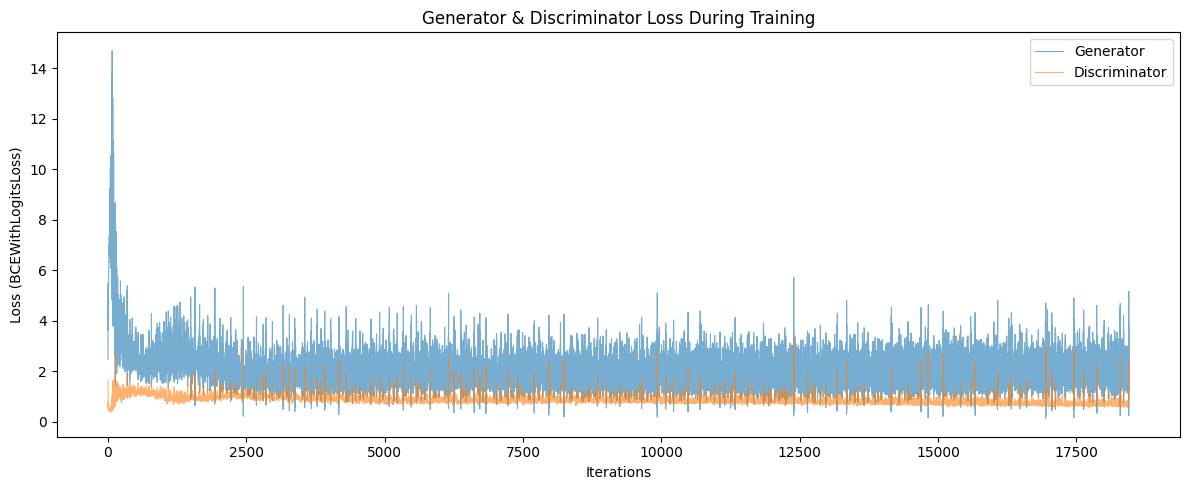

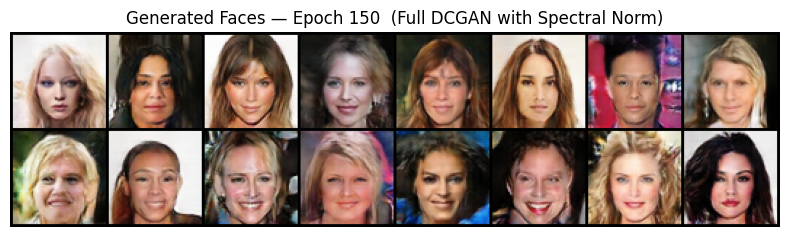

All outputs saved to: /kaggle/working/samples/


In [ ]:
# Resultados finais

# Curvas de perda
plt.figure(figsize=(12, 5))
plt.title("Generator & Discriminator Loss During Training")
plt.plot(G_losses, label="Generator",     alpha=0.6, linewidth=0.8)
plt.plot(D_losses, label="Discriminator", alpha=0.6, linewidth=0.8)
plt.xlabel("Iterations")
plt.ylabel("Loss (BCEWithLogitsLoss)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(sample_dir, "training_losses.png"), dpi=150)
plt.show()

# Amostras finais
generator.eval()
with torch.no_grad():
    fake_samples = generator(fixed_noise).detach().cpu()

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title(f"Generated Faces — Epoch {epochs}  (Full DCGAN with Spectral Norm)")
plt.imshow(
    np.transpose(
        vutils.make_grid(fake_samples, padding=2, normalize=True),
        (1, 2, 0)
    )
)
plt.tight_layout()
plt.savefig(os.path.join(sample_dir, "final_generated_faces.png"), dpi=150)
plt.show()

print(f"All outputs saved to: {sample_dir}/")
